# Brazilian E-Commerce Public Dataset by Olist
Welcome! This is a Brazilian ecommerce public dataset of orders made at Olist Store. The dataset has information of 100k orders from 2016 to 2018 made at multiple marketplaces in Brazil. Its features allows viewing an order from multiple dimensions: from order status, price, payment and freight performance to customer location, product attributes and finally reviews written by customers. We also released a geolocation dataset that relates Brazilian zip codes to lat/lng coordinates.

This is real commercial data, it has been anonymised, and references to the companies and partners in the review text have been replaced with the names of Game of Thrones great houses.

**Context**

This dataset was generously provided by Olist, the largest department store in Brazilian marketplaces. Olist connects small businesses from all over Brazil to channels without hassle and with a single contract. Those merchants are able to sell their products through the Olist Store and ship them directly to the customers using Olist logistics partners. See more on our website: www.olist.com

After a customer purchases the product from Olist Store a seller gets notified to fulfill that order. Once the customer receives the product, or the estimated delivery date is due, the customer gets a satisfaction survey by email where he can give a note for the purchase experience and write down some comments.

**Attention**

1. An order might have multiple items.
2. Each item might be fulfilled by a distinct seller.
3. All text identifying stores and partners where replaced by the names of Game of Thrones great houses.

In [2]:
from IPython.display import Image, display
import requests
import pandas as pd

#use this afer .com/
#uc?export=download&id=

image_1_url="https://drive.google.com/uc?export=download&id=1uYt-TmaBHlTennrSQ4wAhXB-D-pZkh8X"
image_2_url="https://drive.google.com/uc?export=download&id=1gunxmHEW_wftp1hPlc3YglJ2TW7jwS2d"

**Example of a product listing on a marketplace**

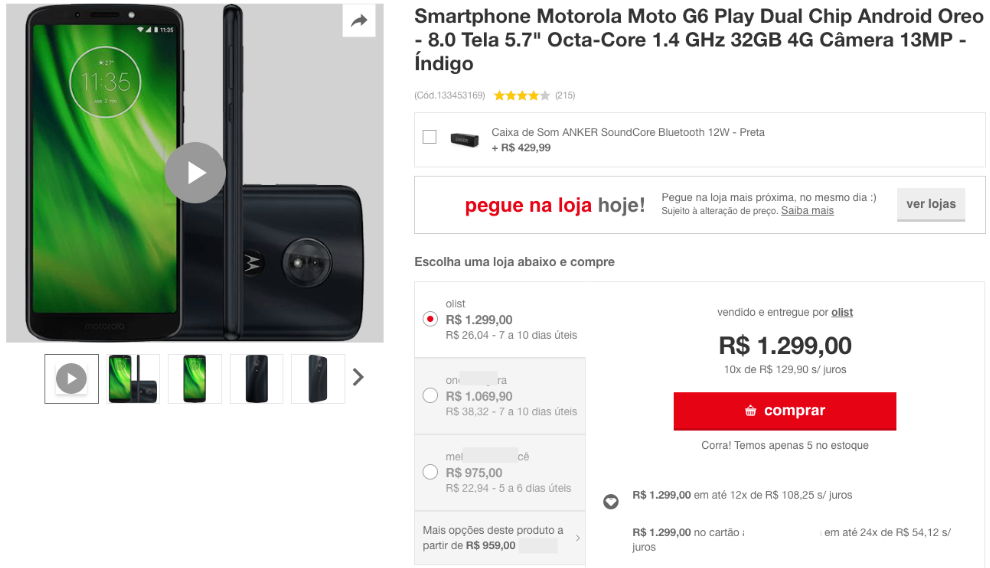

In [2]:
r = requests.get(image_1_url)
display(Image(data=r.content, width=500, height=500))

**Data Schema**

The data is divided in multiple datasets for better understanding and organization. Please refer to the following data schema when working with it:

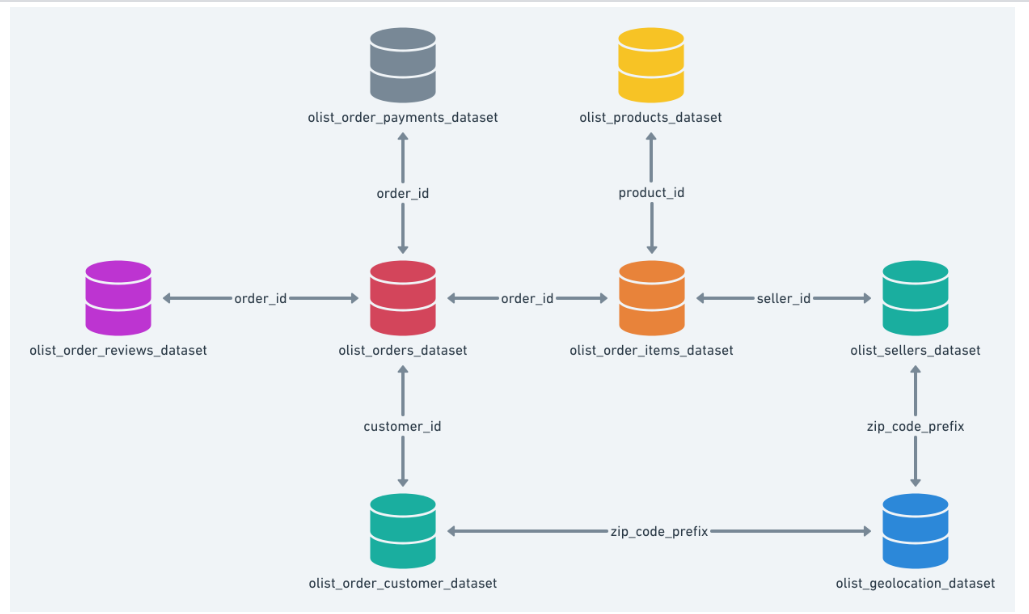

In [3]:
r = requests.get(image_2_url)
display(Image(data=r.content, width=800, height=800))

In [12]:
import duckdb
import numpy as np
import pandas as pd
import sqlite3

In [15]:
#connect to SQLite database
conn=sqlite3.connect("e-commerce.db")  #"e-commerce" is the name of the database

#Covert url:uc?export=download&id=FILE_ID
#Please note that file ID is in GoogleDrive file url between 'd'and 'view'

#url_1: product_category_name_translation.csv
product_category_name_translation_url="https://drive.google.com/uc?export=download&id=1t6KPQXL3pbO3o2igc4Hw6iXBqrYZrW2m"
product_category_name_translation_df=pd.read_csv(product_category_name_translation_url, )
product_category_name_translation_df.to_sql(name="product_translation",  #table name
                                            con=conn,
                                            if_exists="replace",    #replace if table exists
                                            index=False)


#url_2: Olist_sellers_dataset.csv
sellers_dataset_url="https://drive.google.com/uc?export=download&id=1X-EUB4Xqi3lJFRe02fhqcRtzbzj86n71"
sellers_dataset_df=pd.read_csv(sellers_dataset_url)
sellers_dataset_df.to_sql(name="sellers",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_3 Olist_product_dataset.csv
product_dataset_url="https://drive.google.com/uc?export=download&id=1s4T0-L4-LgoUCj0WNU1JVH2-jHXDiWf6"
product_dataset_df=pd.read_csv(product_dataset_url)
product_dataset_df.to_sql(name="products",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_4: Olist_orders_dataset.csv
orders_dataset_url="https://drive.google.com/uc?export=download&id=17aHgy6uZBDZbHHBducCUT7eRgW8_jSWa"
orders_dataset_df=pd.read_csv(orders_dataset_url)
orders_dataset_df.to_sql(name="orders",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_5: Olist_order_reviews_dataset.csv
order_reviews_dataset_url="https://drive.google.com/uc?export=download&id=1iuvggSmrMWWdLZ_J126DpDCE3x-1qhMY"
order_reviews_dataset_df=pd.read_csv(order_reviews_dataset_url)
order_reviews_dataset_df.to_sql(name="orders_reviews",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_6:Olist_order_payment_dataset.csv
order_payment_dataset_url="https://drive.google.com/uc?export=download&id=1r5DiyOGdVQZ8oQyPsEy990Ky-QfE0hxQ"
order_payment_dataset_df=pd.read_csv(order_payment_dataset_url)
order_payment_dataset_df.to_sql(name="orders_payment",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_7: Olist_order_items_dataset.csv
order_items_dataset_url= "https://drive.google.com/uc?export=download&id=1rcR06nFpQSwDnr2B1kehlvwLFv9pbd4L"
order_items_dataset_df=pd.read_csv(order_items_dataset_url)
order_items_dataset_df.to_sql(name="order_items",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_8: Olist_geological_dataset.csv
geological_dataset_url="https://drive.google.com/uc?export=download&id=1yInuQ08Dku-hAFwsz_ISRnWtIF83tAqp"
geological_dataset_df=pd.read_csv(geological_dataset_url)
geological_dataset_df.to_sql(name="geological",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)

#url_9: Olist_customers_dataset
customers_dataset_url="https://drive.google.com/uc?export=download&id=1pmqiqXMAFQobiu9XRrennKJIBtPk37Ku"
customers_dataset_df=pd.read_csv(customers_dataset_url)
customers_dataset_df.to_sql(name="customers",  #table name
                          con=conn,
                          if_exists="replace",    #replace if table exists
                          index=False)


#display(df)

99441

# Query the database to display tables with Structured Query Language (SQL)

In [7]:
#The structure should always be like:
#data=Database(dataset_url=...., table_name="......").table()


In [21]:
result=pd.read_sql_query("""SELECT * FROM product_translation""", conn)
display(result)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [24]:
#Sellers table
result=pd.read_sql_query("""SELECT * FROM sellers""", conn)
display(result)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [19]:
#product table

result=pd.read_sql_query("""SELECT * FROM products""", conn)
display(result)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [25]:
#orders table

result=pd.read_sql_query("""SELECT * FROM orders""", conn)
display(result)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [27]:
#order reviews table

result=pd.read_sql_query("""SELECT * FROM orders_reviews""", conn)
display(result)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [28]:
#order payment table

result=pd.read_sql_query("""SELECT * FROM orders_payment""", conn)
display(result)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [29]:
#order items table

result=pd.read_sql_query("""SELECT * FROM order_items""", conn)
display(result)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [30]:
#geological table

result=pd.read_sql_query("""SELECT * FROM geological""", conn)
display(result)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [31]:
#customers table

result=pd.read_sql_query("""SELECT * FROM customers""", conn)
display(result)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


# Exploratory Data Analysis (EDA) with SQL

This is EDA with SQL on the Olist Brazilian E-Commerce Public Dataset. This is actually the correct professional approach, because it mirrors how real analytics teams work (they don’t start in Python, they start in the warehouse).

SQL EDA is NOT about writing queries.

It is about answering:

1. Demand: what people buy
2. Supply: who sells it
3. Experience: delivery + reviews
4. Money flow: payments + revenue
5. Behavior: repeat customers + basket size

In [38]:

result=pd.read_sql_query("""SELECT 'orders' AS table_name, COUNT(*) FROM orders
UNION ALL
SELECT 'customers', COUNT(*) FROM customers
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'ordes_payments', COUNT(*) FROM orders_payment
UNION ALL
SELECT 'orders_reviews', COUNT(*) FROM orders_reviews;
""",conn) #Use SQL

display(result)

,table_name,COUNT(*)
0,orders,99441
1,customers,99441
2,order_items,112650
3,ordes_payments,103886
4,orders_reviews,99224
